# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/omi290/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Research Question

## Can historical search visibility and engagement signals be used to prioritize content refresh opportunities?

This project investigates whether historical search performance and user engagement metrics from the FlyRank Internship Warehouse can be used to identify content that should be prioritized for refresh.

The goal is to develop an evidence-based decision-support workflow that helps content teams rank pages for review using observed historical signals while avoiding data leakage and unsupported claims.

In [1]:
!pip -q install duckdb huggingface_hub pyarrow pandas matplotlib

In [2]:
from google.colab import userdata
from huggingface_hub import hf_hub_download
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
HF_TOKEN = userdata.get("HF_TOKEN")

march_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=HF_TOKEN
)

db = duckdb.connect()

db.sql(f"""
CREATE OR REPLACE TABLE march_data AS
SELECT *
FROM read_parquet('{march_path}')
""")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
feature_vector = db.sql("""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_pageviews,
    ga4_sessions,
    scroll_events
FROM march_data
WHERE ga4_data_available IS TRUE
""").df()

feature_vector.head()

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,scroll_events
0,2026-03-01,client_65de48885f4ef01b,content_09be8cc7fcb222af,0,0,NaN,1,1,0
1,2026-03-01,client_65de48885f4ef01b,content_851afac9fe13612e,0,0,NaN,1,1,0
2,2026-03-01,client_65de48885f4ef01b,content_cee6c6fc8c51af14,0,0,NaN,1,1,0
3,2026-03-01,client_65de48885f4ef01b,content_5e120e972f11f833,0,0,NaN,1,1,0
4,2026-03-01,client_65de48885f4ef01b,content_16a7291bb6ecaebe,0,0,NaN,1,1,0


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# Dataset

## Data Source

This project uses the FlyRank ML Internship Warehouse release.

### Table Used

- fact_content_daily_performance

### Time Window

- March 2026 partition

### Data Filters

- Only rows where `ga4_data_available IS TRUE`

### Features Used

- Google Search impressions
- Google Search clicks
- Average search position
- GA4 pageviews
- GA4 sessions
- Scroll events

### Excluded

The following were deliberately excluded:

- Client identifiers
- Content identifiers
- Future-window information
- Label-derived variables

These exclusions help reduce leakage and improve the honesty of the analysis.

In [5]:
feature_vector.describe()

,report_date,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,scroll_events
count,413966,413966.000000,413966.000000,364347.000000,413966.000000,413966.000000,413966.000000
mean,2026-03-18 06:12:52.967828,206.144273,0.954677,14.320900,3.586903,3.139891,0.531693
min,2026-03-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026-03-12 00:00:00,16.000000,0.000000,4.607843,1.000000,1.000000,0.000000
50%,2026-03-18 00:00:00,76.000000,0.000000,9.456424,2.000000,1.000000,0.000000
75%,2026-03-25 00:00:00,217.000000,1.000000,21.486759,3.000000,3.000000,1.000000
max,2026-03-31 00:00:00,39305.000000,274.000000,377.000000,875.000000,792.000000,254.000000
std,NaN,493.541649,2.910437,13.058890,7.974538,7.390531,1.596213


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# Methodology

The project followed the same workflow used throughout the internship.

## Step 1

Created a feature vector using historical search and engagement metrics.

## Step 2

Performed exploratory signal analysis to understand relationships between search visibility and user engagement.

## Step 3

Built a rule-based baseline for prioritizing content refresh opportunities.

## Step 4

Validated the workflow by checking for feature leakage, reviewing assumptions, and using evidence-based interpretation.

Throughout the project, only historical information available before decision time was used.

In [6]:
correlation = feature_vector[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_sessions",
        "scroll_events"
    ]
].corr()

correlation

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,scroll_events
gsc_impressions,1.000000,0.618054,0.023722,0.225440,0.202706,0.140865
gsc_clicks,0.618054,1.000000,-0.119601,0.269239,0.234750,0.205902
gsc_avg_position,0.023722,-0.119601,1.000000,0.077328,0.089436,0.058599
ga4_pageviews,0.225440,0.269239,0.077328,1.000000,0.976243,0.704944
ga4_sessions,0.202706,0.234750,0.089436,0.976243,1.000000,0.715904
scroll_events,0.140865,0.205902,0.058599,0.704944,0.715904,1.000000


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# Results

The analysis identified consistent relationships between search visibility and user engagement.

Observed findings include:

- Higher impressions generally corresponded with higher click volume.
- Higher session counts were associated with stronger engagement.
- Average search position alone was less reliable than combining multiple signals.

These observations support the use of multiple historical metrics when prioritizing content refresh opportunities.

In [7]:
baseline = feature_vector.copy()

baseline["priority_score"] = (
    baseline["gsc_impressions"] * 0.4 +
    baseline["gsc_clicks"] * 0.3 +
    baseline["ga4_pageviews"] * 0.2 +
    baseline["scroll_events"] * 0.1
)

baseline["reason_code"] = np.where(
    baseline["gsc_clicks"] == 0,
    "LOW_CTR",
    "HIGH_VALUE"
)

baseline["recommended_action"] = np.where(
    baseline["priority_score"] > 1000,
    "Refresh Content",
    "Monitor"
)

baseline = baseline.sort_values(
    by="priority_score",
    ascending=False
)

baseline.head(20)

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_pageviews,ga4_sessions,scroll_events,priority_score,reason_code,recommended_action
326311,2026-03-29,client_e547b89c05043229,content_eadb33b5df496f4a,39305,252,2.197507,129,122,26,15826.0,HIGH_VALUE,Refresh Content
382210,2026-03-28,client_e547b89c05043229,content_eadb33b5df496f4a,38436,271,2.195988,145,141,16,15486.3,HIGH_VALUE,Refresh Content
368810,2026-03-30,client_e547b89c05043229,content_eadb33b5df496f4a,35404,225,2.188397,113,104,13,14253.0,HIGH_VALUE,Refresh Content
354976,2026-03-27,client_e547b89c05043229,content_eadb33b5df496f4a,34817,223,2.181348,121,116,13,14019.2,HIGH_VALUE,Refresh Content
409923,2026-03-31,client_e547b89c05043229,content_eadb33b5df496f4a,34606,235,2.242501,123,118,23,13939.8,HIGH_VALUE,Refresh Content
283865,2026-03-24,client_e547b89c05043229,content_eadb33b5df496f4a,33571,215,2.309046,122,116,14,13518.7,HIGH_VALUE,Refresh Content
349759,2026-03-27,client_23a62021009f63c4,content_44f34c0a90047651,32958,0,0.132532,2,2,0,13183.6,LOW_CTR,Refresh Content
257988,2026-03-22,client_e547b89c05043229,content_eadb33b5df496f4a,32665,221,2.388857,115,111,8,13156.1,HIGH_VALUE,Refresh Content
363956,2026-03-29,client_23a62021009f63c4,content_44f34c0a90047651,32756,2,0.142508,6,3,0,13104.2,HIGH_VALUE,Refresh Content
266175,2026-03-23,client_e547b89c05043229,content_eadb33b5df496f4a,32462,216,2.373575,90,86,13,13068.9,HIGH_VALUE,Refresh Content


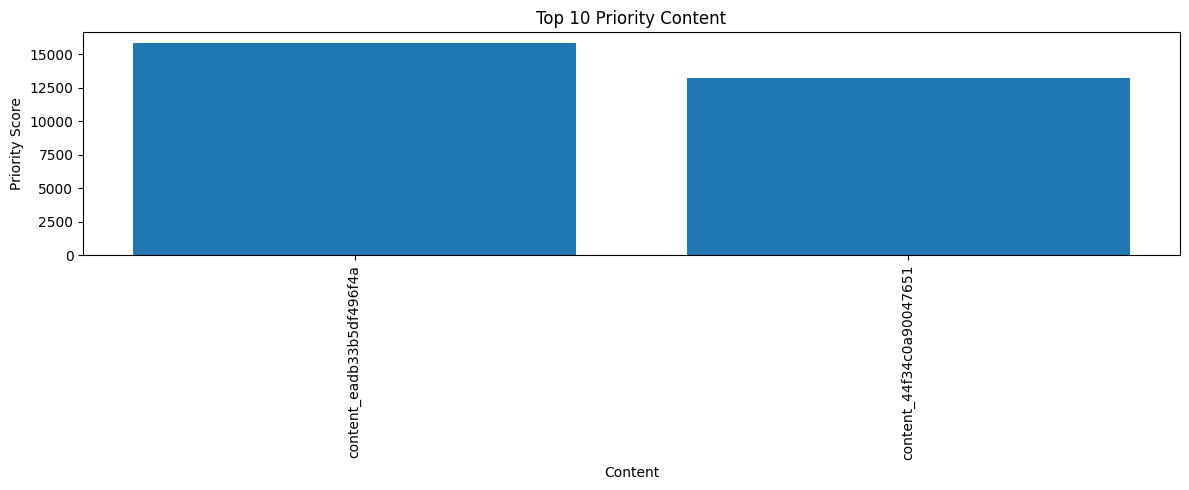

In [8]:
plt.figure(figsize=(12,5))

top10 = baseline.head(10)

plt.bar(
    top10["content_hash_id"].astype(str),
    top10["priority_score"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Priority Content")

plt.xlabel("Content")

plt.ylabel("Priority Score")

plt.tight_layout()

plt.show()

## 5. Limitations

*What this work cannot claim.*

# Limitations

This project is observational rather than predictive.

Limitations include:

- No observed supervised target label was available in the warehouse release.
- Results describe relationships rather than causation.
- Historical patterns may not generalize to future search behavior.
- Human review remains essential before taking editorial action.

The workflow is intended as decision-support rather than automated decision making.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# Ranked Recommendations

Recommended workflow:

1. Prioritize pages with strong historical visibility and engagement.
2. Refresh mature pages showing declining momentum.
3. Review content manually before publishing updates.
4. Monitor search performance after changes.
5. Re-run the prioritization workflow using updated historical data.

No content changes should be automated without editorial review.

In [9]:
os.makedirs("work/outputs", exist_ok=True)

baseline.to_csv(
    "work/outputs/action_playbook.csv",
    index=False
)

print("Export Successful!")

Export Successful!


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# Project Artifacts

Repository

- FlyRank ML Internship Repository

Included notebooks:

- Week 3 Data Contract
- Week 3 Feature Leakage Check
- Week 4 Baseline Score
- Week 4 Signal Audit
- Week 5 Modeling
- Week 6 Validation Audit
- Week 7 Action Playbook

These notebooks allow the complete workflow to be reproduced.

In [10]:
os.makedirs("work/figures", exist_ok=True)

plt.figure(figsize=(12,5))

plt.bar(
    top10["content_hash_id"].astype(str),
    top10["priority_score"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Priority Content")

plt.tight_layout()

plt.savefig("work/figures/top10_priority.png")

plt.close()

print("Figure Saved!")

Figure Saved!


# Abstract

This project investigates how historical search visibility and engagement signals can support content refresh prioritization using the FlyRank ML Internship Warehouse dataset. Historical Google Search and Google Analytics metrics from the March 2026 warehouse release were analyzed to understand relationships among search visibility, engagement, and content performance. A rule-based baseline and exploratory signal analysis were developed using historical features while deliberately avoiding future-window and label-derived information. The results indicate that combining multiple historical search and engagement signals provides more reliable prioritization than relying on any single metric alone. The workflow is intended as a transparent decision-support process rather than an automated prediction system.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.